# Learning Detection Comparison (Strategies 1–3)

This notebook:
1) Runs Bayesian strategy analysis for multiple strategies (Figure 1-style)
2) Selects the dominant rule strategy automatically (go_left/go_right/go_cued)
3) Computes learning trial using:
   - Strategy 1: Sequence criterion
   - Strategy 2: Sequence + Precision
   - Strategy 3: Expert (posterior excludes chance)
4) Plots all learning trials on the rule-strategy MAP plot

In [11]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials
from scipy.stats import beta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


In [12]:
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]

strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")

In [13]:
alpha0, beta0 = set_priors(prior_type)

Output_collection = {}
event_totals = {}

for s in strategies:
    Output_collection[s] = pd.DataFrame(columns=[
        "Alpha", "Beta",
        "MAPprobability", "Precision",
        "Alpha_interpolated", "Beta_interpolated",
        "MAPprobability_interpolated", "Precision_interpolated"
    ])
    event_totals[s] = {"success_total": 0, "failure_total": 0}

In [14]:
for trial in range(len(TestData)):

    rows_of_data = TestData.iloc[0:trial+1]

    for s in strategies:

        trial_type = strategy_functions[s](rows_of_data)

        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[s]["success_total"],
            event_totals[s]["failure_total"],
            alpha0,
            beta0
        )

        event_totals[s]["success_total"] = success_total
        event_totals[s]["failure_total"] = failure_total

        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }

        if trial > 0:
            previous_trials_data = Output_collection[s].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[s]

        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )

        Output_collection[s] = pd.concat(
            [Output_collection[s], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_14238/2211875573.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[s] = pd.concat(


In [15]:
final_MAPs = {s: Output_collection[s]["MAPprobability"].iloc[-1] for s in rule_strategies}
target_strategy = max(final_MAPs, key=final_MAPs.get)

print("Final MAPs (rule strategies):", final_MAPs)
print("Dominant rule strategy:", target_strategy)

Final MAPs (rule strategies): {'go_left': np.float64(0.14), 'go_right': np.float64(0.86), 'go_cued': np.float64(0.999)}
Dominant rule strategy: go_cued


In [16]:
def learning_trial_sequence(MAP, chance=0.5):
    MAP = np.asarray(MAP)
    for t in range(len(MAP)):
        if np.all(MAP[t:] > chance):
            return t
    return None


def learning_trial_sequence_precision(Output_collection,
                                      target,
                                      others,
                                      chance=0.5):
    MAP_t  = Output_collection[target]["MAPprobability"].values
    PREC_t = Output_collection[target]["Precision"].values

    PREC_others = np.vstack([Output_collection[o]["Precision"].values for o in others])
    max_other = PREC_others.max(axis=0)

    for t in range(len(MAP_t)):
        if np.all(MAP_t[t:] > chance) and (PREC_t[t] >= max_other[t]):
            return t
    return None


def learning_trial_expert(Output_collection,
                          target,
                          chance=0.5,
                          prob_thresh=0.95):
    A = Output_collection[target]["Alpha"].values
    B = Output_collection[target]["Beta"].values

    # P(p > chance) under Beta(A,B)
    p_gt = 1.0 - beta.cdf(chance, A, B)

    for t in range(len(p_gt)):
        if np.all(p_gt[t:] >= prob_thresh):
            return t
    return None

In [17]:
MAP = Output_collection[target_strategy]["MAPprobability"].values

t1 = learning_trial_sequence(MAP, chance=0.5)
t2 = learning_trial_sequence_precision(Output_collection, target=target_strategy, others=others, chance=0.5)
t3 = learning_trial_expert(Output_collection, target=target_strategy, chance=0.5, prob_thresh=0.95)

print("Learning trials:", {"Strategy1": t1, "Strategy2": t2, "Strategy3": t3})

Learning trials: {'Strategy1': 0, 'Strategy2': 0, 'Strategy3': 3}


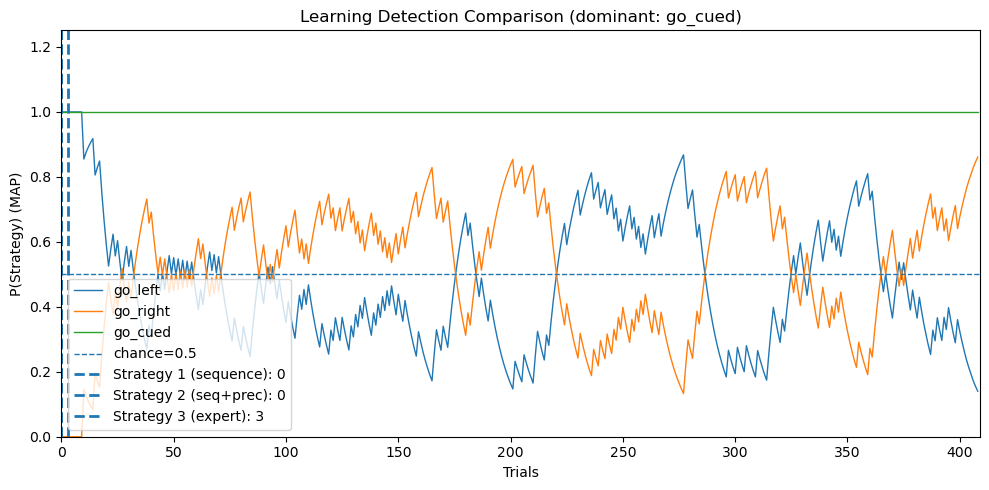

In [18]:
plt.figure(figsize=(10, 5))

for s in rule_strategies:
    plt.plot(Output_collection[s]["MAPprobability"], label=s, linewidth=1.0)

plt.axhline(0.5, linestyle="--", linewidth=1.0, label="chance=0.5")

if t1 is not None:
    plt.axvline(t1, linestyle="--", linewidth=2, label=f"Strategy 1 (sequence): {t1}")
if t2 is not None:
    plt.axvline(t2, linestyle="--", linewidth=2, label=f"Strategy 2 (seq+prec): {t2}")
if t3 is not None:
    plt.axvline(t3, linestyle="--", linewidth=2, label=f"Strategy 3 (expert): {t3}")

try:
    plotSessionStructure(TestData)
except Exception:
    pass

plt.axis([0, no_Trials, 0, 1.25])
plt.xlabel("Trials")
plt.ylabel("P(Strategy) (MAP)")
plt.title(f"Learning Detection Comparison (dominant: {target_strategy})")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
df_results = pd.DataFrame({
    "Criterion": ["Sequence", "Sequence + Precision", "Expert"],
    "Learning Trial": [t1, t2, t3]
})

df_results

,Criterion,Learning Trial
0,Sequence,0
1,Sequence + Precision,0
2,Expert,3
